# Solar's Impact on the German Electricity Market
## Data Loading
Two datasets from SMARD.de (German Federal Network Agency):
- Electricity production by source (15-min intervals, 2020-2025)
- Day-ahead spot prices (15-min intervals, 2020-2025)

In [1]:
import pandas as pd

df_prod = pd.read_csv(
    "Realisierte_Erzeugung_202001010000_202601010000_Viertelstunde.csv",
    sep=";",
    decimal=",",
    thousands=".",
    encoding="utf-8-sig"
)

df_price = pd.read_csv(
    "Gro_handelspreise_202001010000_202601010000_Viertelstunde.csv",
    sep=";",
    decimal=",",
    thousands=".",
    encoding="utf-8-sig"
)

print(df_prod.shape)
print(df_prod.columns.tolist())
print("---")
print(df_price.shape)
print(df_price.columns.tolist())

/var/folders/xb/h7qh66p54w9_67dy7f9bbvdm0000gn/T/ipykernel_22785/4261551399.py:3: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  df_prod = pd.read_csv(


(210432, 14)
['Datum von', 'Datum bis', 'Biomasse [MWh] Originalauflösungen', 'Wasserkraft [MWh] Originalauflösungen', 'Wind Offshore [MWh] Originalauflösungen', 'Wind Onshore [MWh] Originalauflösungen', 'Photovoltaik [MWh] Originalauflösungen', 'Sonstige Erneuerbare [MWh] Originalauflösungen', 'Kernenergie [MWh] Originalauflösungen', 'Braunkohle [MWh] Originalauflösungen', 'Steinkohle [MWh] Originalauflösungen', 'Erdgas [MWh] Originalauflösungen', 'Pumpspeicher [MWh] Originalauflösungen', 'Sonstige Konventionelle [MWh] Originalauflösungen']
---
(210432, 19)
['Datum von', 'Datum bis', 'Deutschland/Luxemburg [€/MWh] Originalauflösungen', '∅ Anrainer DE/LU [€/MWh] Originalauflösungen', 'Belgien [€/MWh] Originalauflösungen', 'Dänemark 1 [€/MWh] Originalauflösungen', 'Dänemark 2 [€/MWh] Originalauflösungen', 'Frankreich [€/MWh] Originalauflösungen', 'Niederlande [€/MWh] Originalauflösungen', 'Norwegen 2 [€/MWh] Originalauflösungen', 'Österreich [€/MWh] Originalauflösungen', 'Polen [€/MWh] 

## Data Cleaning & Preprocessing
- Renamed columns to English
- Converted datetime and numeric types
- Filled nuclear nulls with 0 (plants shut down in 2023)
- Merged datasets on datetime

In [4]:
df_prod = pd.read_csv(
    "Realisierte_Erzeugung_202001010000_202601010000_Viertelstunde.csv",
    sep=";", decimal=",", thousands=".", encoding="utf-8-sig", low_memory=False
)

df_prod.columns = [
    "datetime_from", "datetime_to", "biomass", "hydro", "wind_offshore",
    "wind_onshore", "solar", "other_renewables", "nuclear", "lignite",
    "hard_coal", "gas", "pumped_storage", "other_conventional"
]

df_price.columns = [
    "datetime_from", "datetime_to", "price_de", "price_avg_neighbors",
    "price_be", "price_dk1", "price_dk2", "price_fr", "price_nl",
    "price_no2", "price_at", "price_pl", "price_se4", "price_ch",
    "price_cz", "price_de_at_lu", "price_it", "price_si", "price_hu"
]

df = pd.merge(df_prod, df_price[["datetime_from", "price_de"]], on="datetime_from", how="inner")

print(df.shape)
print(df.head())

(210480, 15)
      datetime_from       datetime_to  biomass   hydro  wind_offshore  \
0  01.01.2020 00:00  01.01.2020 00:15  1202.25  442.75         125.25   
1  01.01.2020 00:15  01.01.2020 00:30  1200.75  425.50         125.25   
2  01.01.2020 00:30  01.01.2020 00:45  1196.75  396.50         135.00   
3  01.01.2020 00:45  01.01.2020 01:00  1196.75  352.50         163.75   
4  01.01.2020 01:00  01.01.2020 01:15  1196.25  388.75         222.50   

   wind_onshore  solar  other_renewables   nuclear  lignite  hard_coal  \
0       1482.25    0.0             58.50  2.024,00   2320.0     496.25   
1       1481.25    0.0             58.00  2.020,75   2326.0     487.00   
2       1532.25    0.0             57.75  2.020,50   2334.0     485.50   
3       1565.25    0.0             57.75  2.019,50   2337.0     493.00   
4       1528.75    0.0             57.75  2.022,75   2352.0     484.00   

       gas  pumped_storage  other_conventional  price_de  
0  1552.25          256.50              437.

In [8]:
df.dtypes

datetime_from          object
datetime_to            object
biomass               float64
hydro                 float64
wind_offshore         float64
wind_onshore          float64
solar                 float64
other_renewables      float64
nuclear                object
lignite               float64
hard_coal             float64
gas                   float64
pumped_storage        float64
other_conventional    float64
price_de              float64
dtype: object

In [9]:
df["datetime_from"] = pd.to_datetime(df["datetime_from"], format="%d.%m.%Y %H:%M")
df["datetime_to"] = pd.to_datetime(df["datetime_to"], format="%d.%m.%Y %H:%M")

df["nuclear"] = df["nuclear"].str.replace(".", "", regex=False).str.replace(",", ".", regex=False)
df["nuclear"] = pd.to_numeric(df["nuclear"], errors="coerce")

print(df.dtypes)
print(df["nuclear"].isnull().sum())

datetime_from         datetime64[ns]
datetime_to           datetime64[ns]
biomass                      float64
hydro                        float64
wind_offshore                float64
wind_onshore                 float64
solar                        float64
other_renewables             float64
nuclear                      float64
lignite                      float64
hard_coal                    float64
gas                          float64
pumped_storage               float64
other_conventional           float64
price_de                     float64
dtype: object
67358


In [11]:
null_counts = df.isnull().sum()
null_pct = (null_counts / len(df)) * 100
print(pd.DataFrame({"null_count": null_counts, "null_pct": null_pct.round(2)}))

                    null_count  null_pct
datetime_from                0       0.0
datetime_to                  0       0.0
biomass                      0       0.0
hydro                        0       0.0
wind_offshore                0       0.0
wind_onshore                 0       0.0
solar                        0       0.0
other_renewables             0       0.0
nuclear                  67358      32.0
lignite                      0       0.0
hard_coal                    0       0.0
gas                          0       0.0
pumped_storage               0       0.0
other_conventional           0       0.0
price_de                     0       0.0


In [12]:
df["nuclear"] = df["nuclear"].fillna(0)
print(df.isnull().sum().sum())

0


## Exploratory Data Analysis

In [14]:
df.describe()

,datetime_from,datetime_to,biomass,hydro,wind_offshore,wind_onshore,solar,other_renewables,nuclear,lignite,hard_coal,gas,pumped_storage,other_conventional,price_de
count,210480,210480,210480.000000,210480.000000,210480.000000,210480.000000,210480.000000,210480.000000,210480.000000,210480.000000,210480.000000,210480.000000,210480.000000,210480.000000,210480.000000
mean,2023-01-01 01:06:17.137970688,2023-01-01 01:21:14.675028480,1070.672002,429.540390,717.760022,3003.611422,1616.396271,35.838883,788.336182,2381.118729,1163.360431,1625.346826,283.641106,398.879092,104.236317
min,2020-01-01 00:00:00,2020-01-01 00:15:00,768.390000,208.750000,0.000000,10.500000,0.000000,12.370000,0.000000,467.250000,32.750000,313.500000,0.000000,191.750000,-500.000000
25%,2021-07-02 01:56:15,2021-07-02 02:11:15,1014.250000,348.250000,268.750000,1108.500000,0.750000,28.250000,0.000000,1623.500000,518.500000,936.000000,33.250000,352.750000,43.900000
50%,2022-12-31 23:52:30,2023-01-01 00:07:30,1076.725000,421.250000,663.750000,2307.250000,29.250000,33.000000,703.500000,2516.000000,935.500000,1463.750000,125.250000,393.250000,85.010000
75%,2024-07-02 01:48:45,2024-07-02 02:03:45,1132.750000,500.000000,1146.750000,4350.735000,2558.272500,43.000000,1645.750000,3098.500000,1606.000000,2157.500000,430.107500,449.750000,124.692500
max,2025-12-31 23:45:00,2026-01-01 00:00:00,1320.500000,815.500000,2091.890000,12151.750000,13209.000000,61.250000,2052.000000,4300.250000,4100.000000,5063.750000,2096.750000,682.590000,936.280000
std,NaN,NaN,83.920442,103.602415,489.838221,2397.513880,2518.449319,9.600758,803.238519,899.882339,819.574875,854.802589,349.374121,67.648605,97.953879


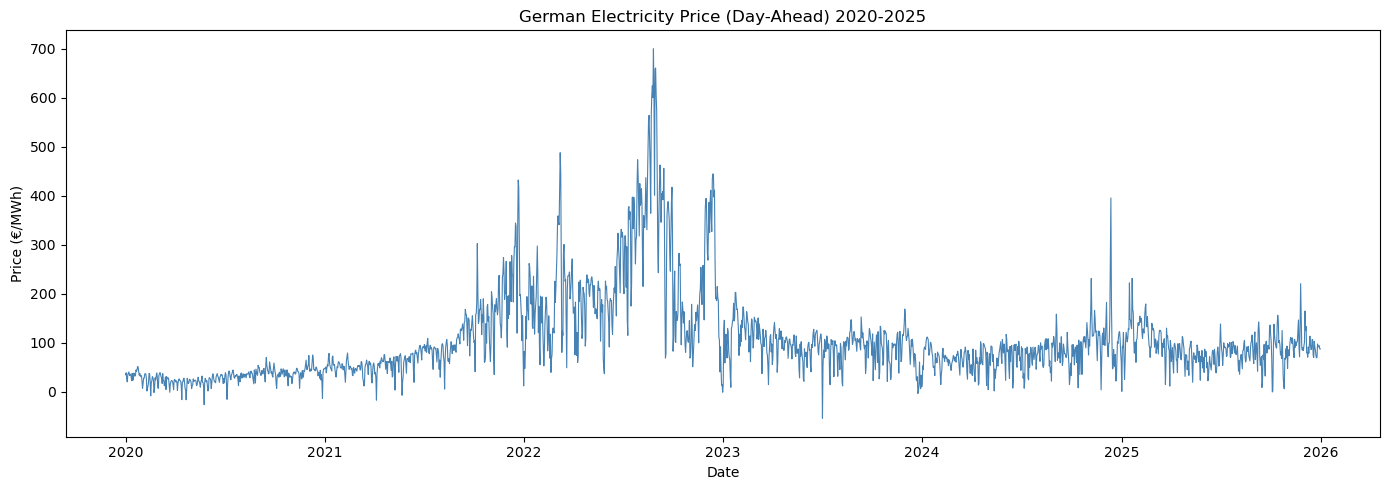

In [15]:
import matplotlib.pyplot as plt

df_daily = df.groupby(df["datetime_from"].dt.date)["price_de"].mean().reset_index()
df_daily.columns = ["date", "price_de"]

plt.figure(figsize=(14, 5))
plt.plot(df_daily["date"], df_daily["price_de"], color="steelblue", linewidth=0.8)
plt.title("German Electricity Price (Day-Ahead) 2020-2025")
plt.xlabel("Date")
plt.ylabel("Price (€/MWh)")
plt.tight_layout()
plt.show()

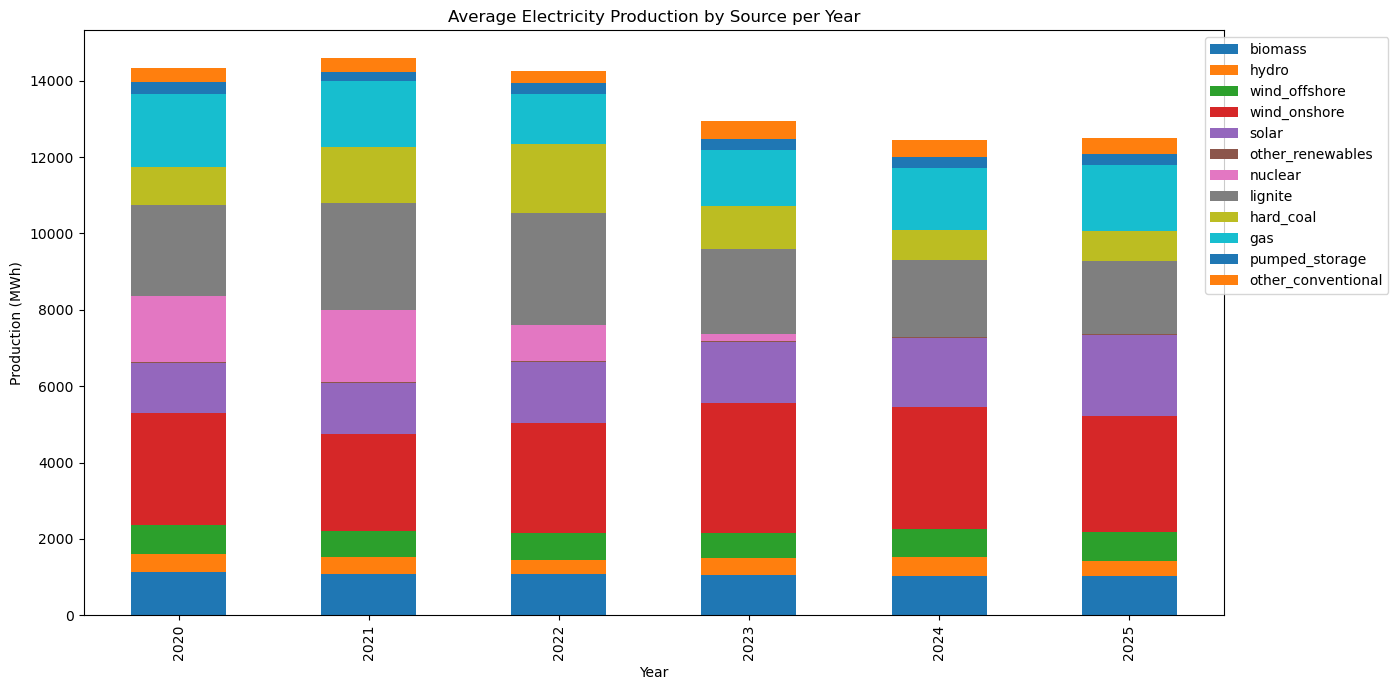

In [16]:
energy_cols = ["biomass", "hydro", "wind_offshore", "wind_onshore", 
               "solar", "other_renewables", "nuclear", "lignite", 
               "hard_coal", "gas", "pumped_storage", "other_conventional"]

df["year"] = df["datetime_from"].dt.year
df_yearly = df.groupby("year")[energy_cols].mean()

df_yearly.plot(kind="bar", stacked=True, figsize=(14, 7))
plt.title("Average Electricity Production by Source per Year")
plt.xlabel("Year")
plt.ylabel("Production (MWh)")
plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))
plt.tight_layout()
plt.show()

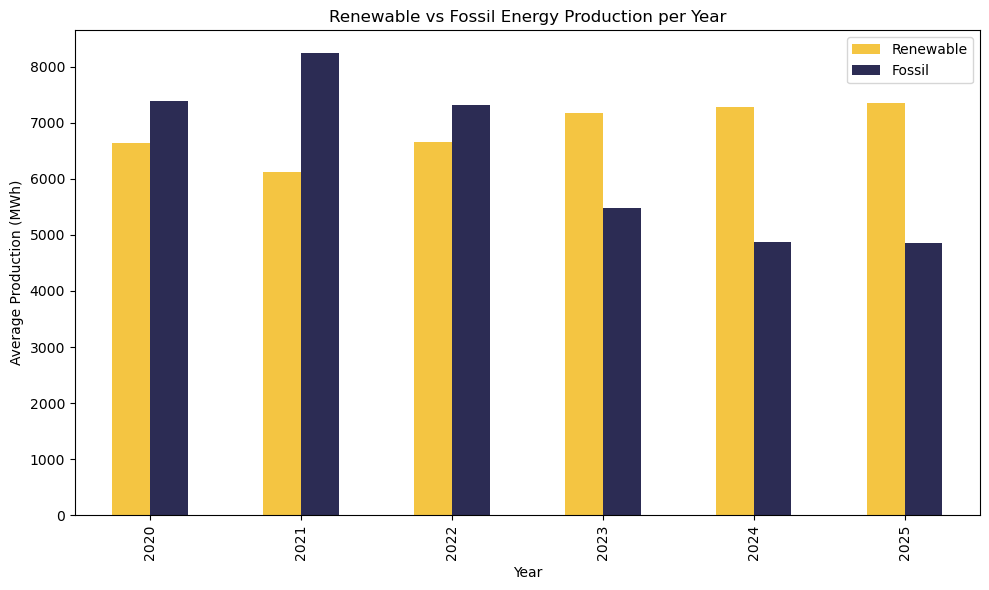

In [17]:
df["renewable"] = df[["biomass", "hydro", "wind_offshore", "wind_onshore", 
                        "solar", "other_renewables"]].sum(axis=1)

df["fossil"] = df[["lignite", "hard_coal", "gas", "nuclear", 
                    "other_conventional"]].sum(axis=1)

df_yearly_rf = df.groupby("year")[["renewable", "fossil"]].mean()

df_yearly_rf.plot(kind="bar", figsize=(10, 6), 
                  color=["#f4c542", "#2c2c54"])
plt.title("Renewable vs Fossil Energy Production per Year")
plt.xlabel("Year")
plt.ylabel("Average Production (MWh)")
plt.legend(["Renewable", "Fossil"])
plt.tight_layout()
plt.show()

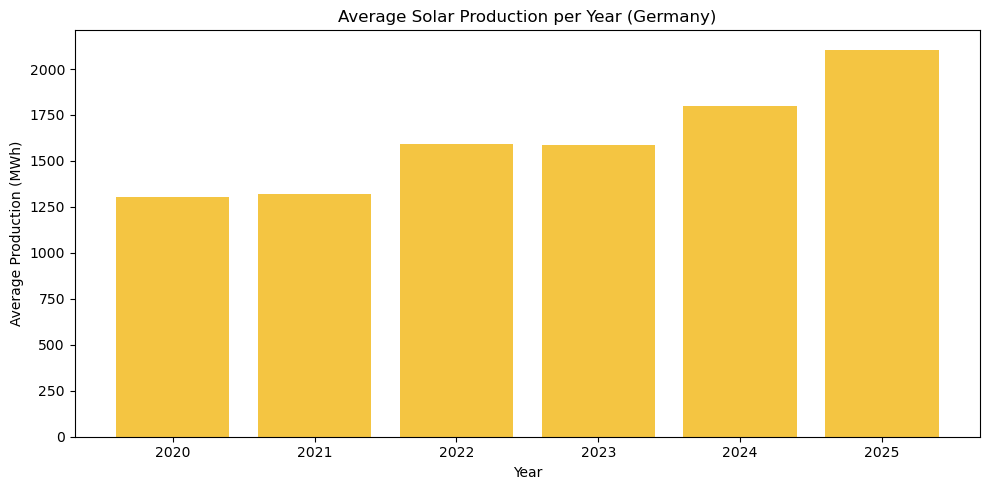

In [19]:
df_solar_yearly = df.groupby("year")["solar"].mean().reset_index()

plt.figure(figsize=(10, 5))
plt.bar(df_solar_yearly["year"], df_solar_yearly["solar"], color="#f4c542")
plt.title("Average Solar Production per Year (Germany)")
plt.xlabel("Year")
plt.ylabel("Average Production (MWh)")
plt.tight_layout()
plt.show()

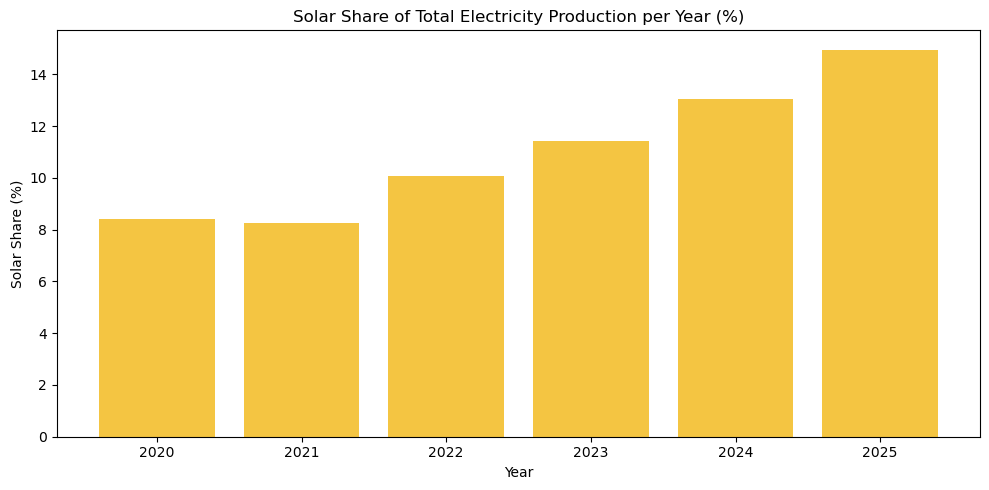

In [20]:
df["total_production"] = df[["biomass", "hydro", "wind_offshore", "wind_onshore",
                              "solar", "other_renewables", "nuclear", "lignite",
                              "hard_coal", "gas", "pumped_storage", "other_conventional"]].sum(axis=1)

df["solar_pct"] = (df["solar"] / df["total_production"]) * 100

df_solar_pct = df.groupby("year")["solar_pct"].mean().reset_index()

plt.figure(figsize=(10, 5))
plt.bar(df_solar_pct["year"], df_solar_pct["solar_pct"], color="#f4c542")
plt.title("Solar Share of Total Electricity Production per Year (%)")
plt.xlabel("Year")
plt.ylabel("Solar Share (%)")
plt.tight_layout()
plt.show()

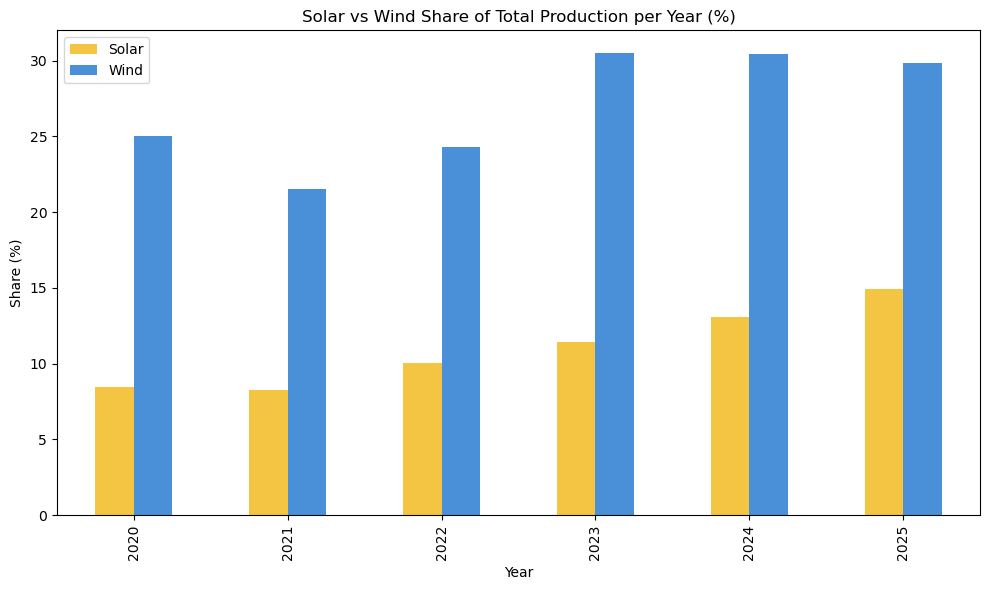

In [21]:
df["wind_total"] = df["wind_offshore"] + df["wind_onshore"]
df["wind_pct"] = (df["wind_total"] / df["total_production"]) * 100

df_compare = df.groupby("year")[["solar_pct", "wind_pct"]].mean()

df_compare.plot(kind="bar", figsize=(10, 6), color=["#f4c542", "#4a90d9"])
plt.title("Solar vs Wind Share of Total Production per Year (%)")
plt.xlabel("Year")
plt.ylabel("Share (%)")
plt.legend(["Solar", "Wind"])
plt.tight_layout()
plt.show()

In [22]:
df[["biomass", "hydro", "wind_offshore", "wind_onshore", "solar", 
    "other_renewables", "nuclear", "lignite", "hard_coal", "gas", 
    "pumped_storage", "other_conventional"]].mean().sort_values(ascending=False)

wind_onshore          3003.611422
lignite               2381.118729
gas                   1625.346826
solar                 1616.396271
hard_coal             1163.360431
biomass               1070.672002
nuclear                788.336182
wind_offshore          717.760022
hydro                  429.540390
other_conventional     398.879092
pumped_storage         283.641106
other_renewables        35.838883
dtype: float64

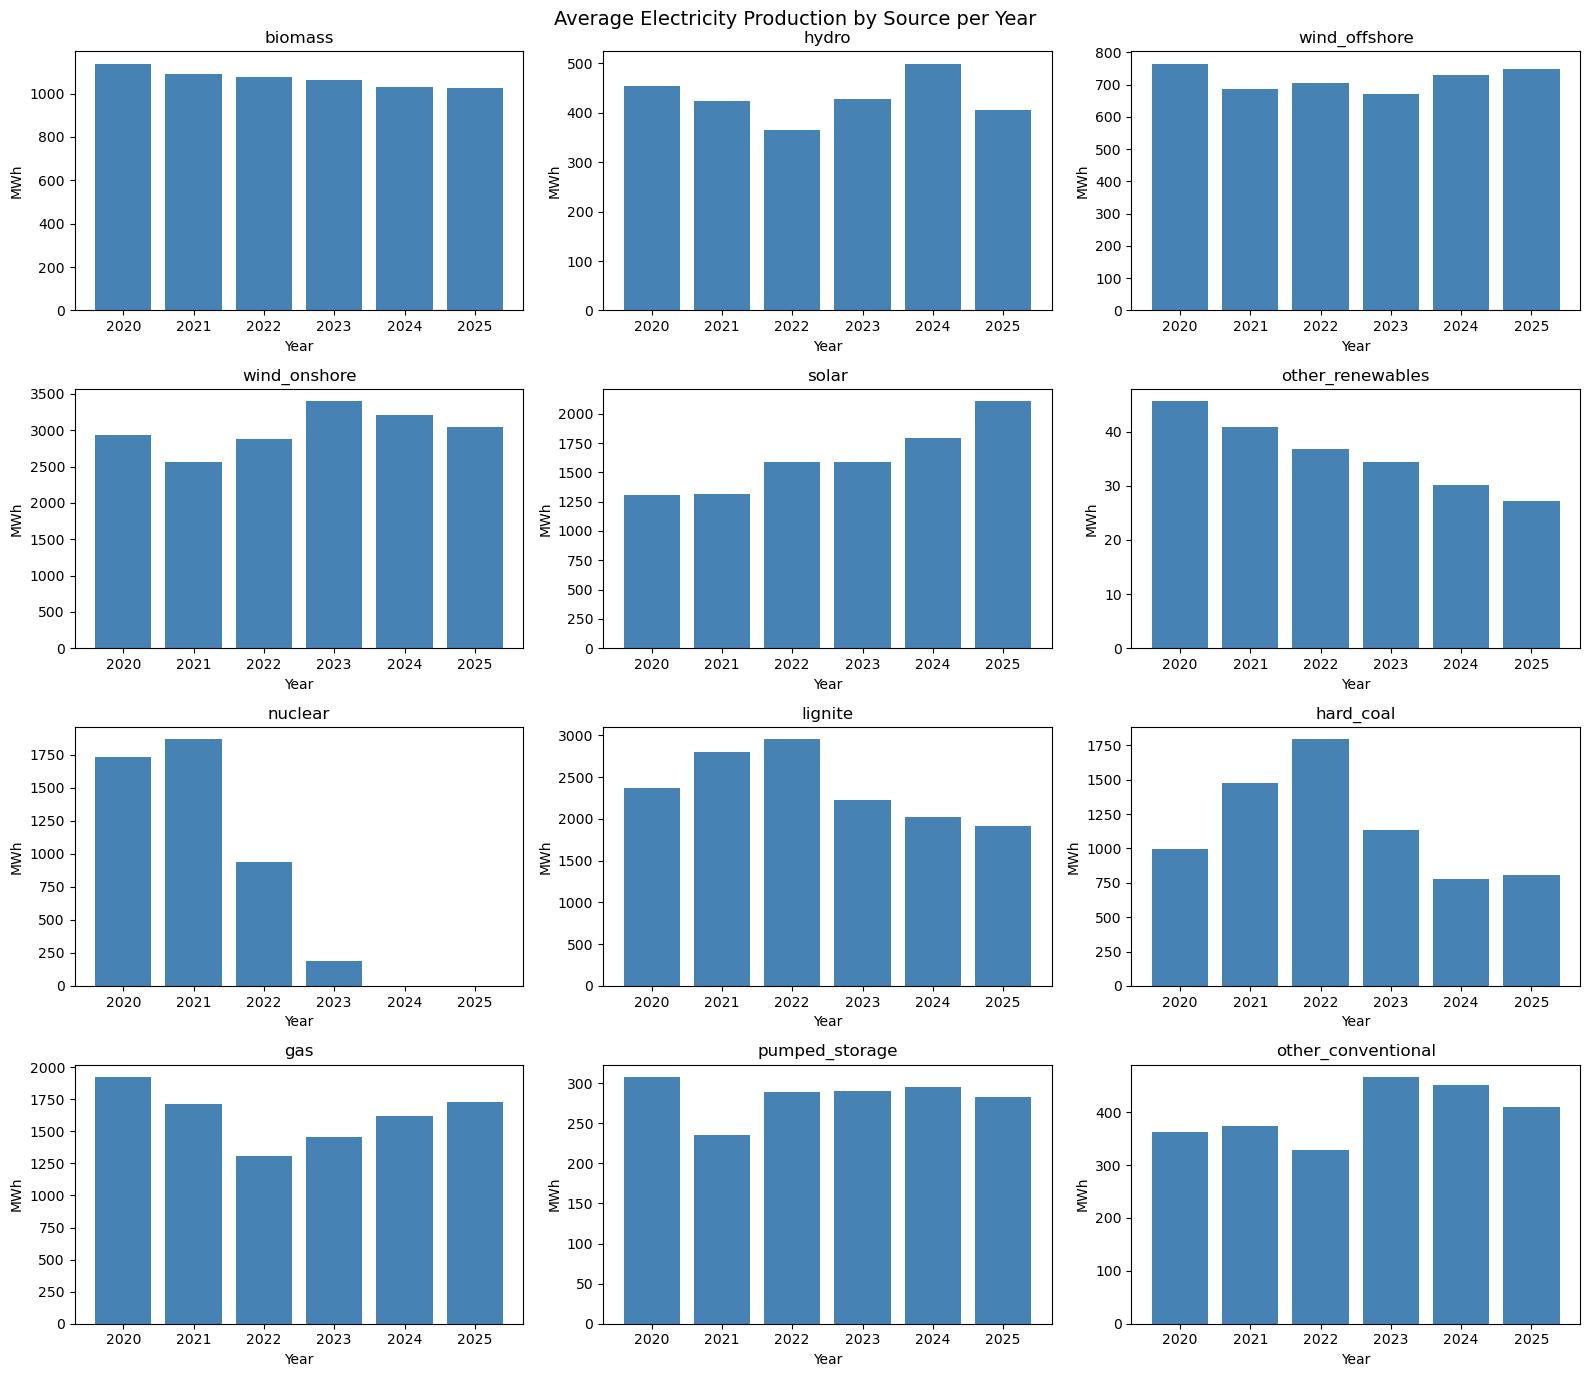

In [24]:
fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(energy_cols):
    axes[i].bar(df_yearly.index, df_yearly[col], color="steelblue")
    axes[i].set_title(col)
    axes[i].set_xlabel("Year")
    axes[i].set_ylabel("MWh")
    axes[i].set_xticks(df_yearly.index)

plt.suptitle("Average Electricity Production by Source per Year", fontsize=14)
plt.tight_layout()
plt.show()

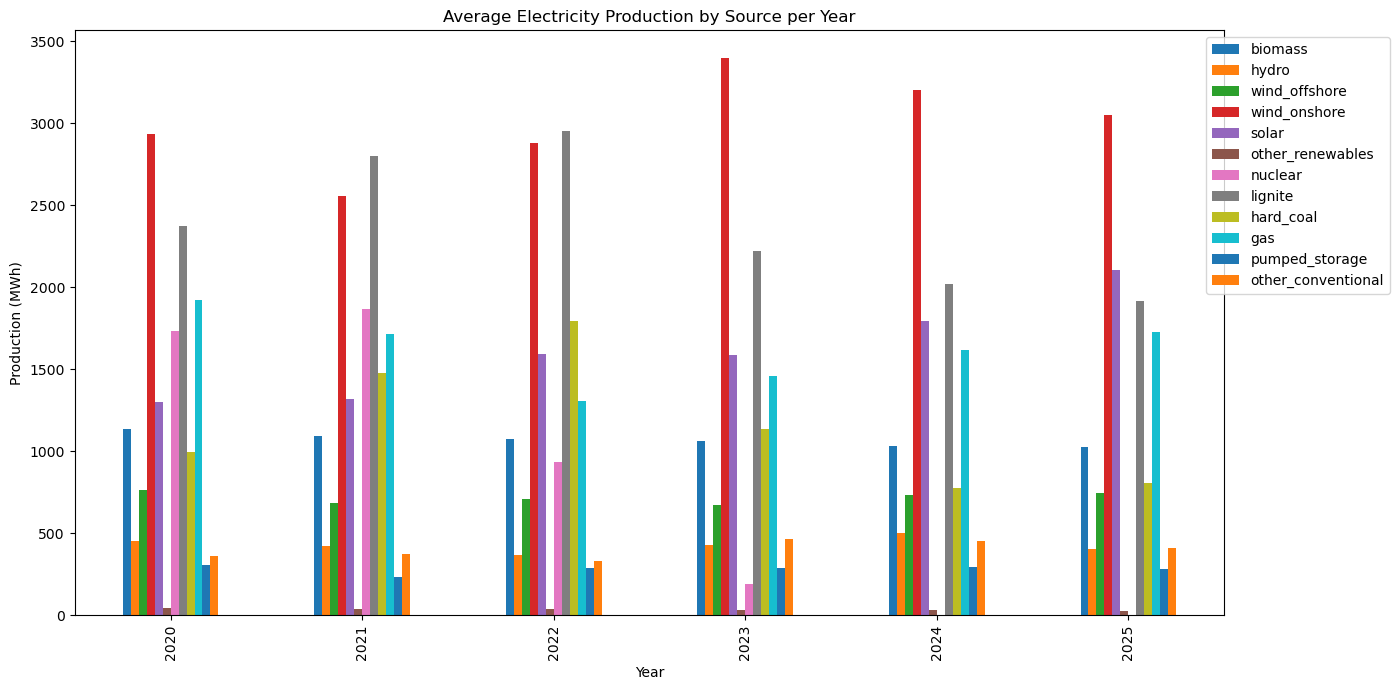

In [26]:
energy_cols = ["biomass", "hydro", "wind_offshore", "wind_onshore", 
               "solar", "other_renewables", "nuclear", "lignite", 
               "hard_coal", "gas", "pumped_storage", "other_conventional"]
df["year"] = df["datetime_from"].dt.year
df_yearly = df.groupby("year")[energy_cols].mean()
df_yearly.plot(kind="bar", stacked=False, figsize=(14, 7))
plt.title("Average Electricity Production by Source per Year")
plt.xlabel("Year")
plt.ylabel("Production (MWh)")
plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))
plt.tight_layout()
plt.show()

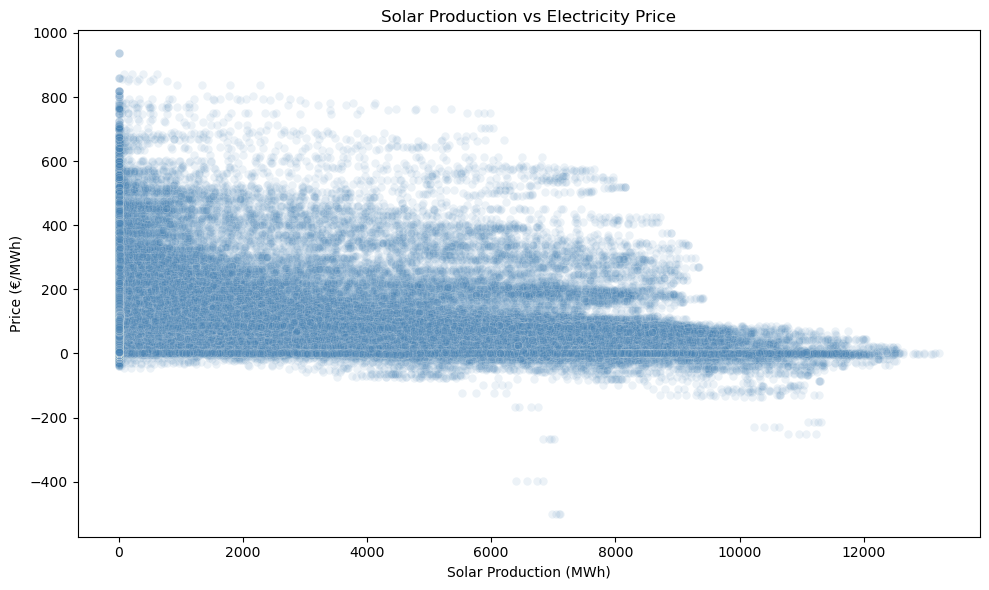

In [28]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="solar", y="price_de", alpha=0.1, color="steelblue")
plt.title("Solar Production vs Electricity Price")
plt.xlabel("Solar Production (MWh)")
plt.ylabel("Price (€/MWh)")
plt.tight_layout()
plt.show()


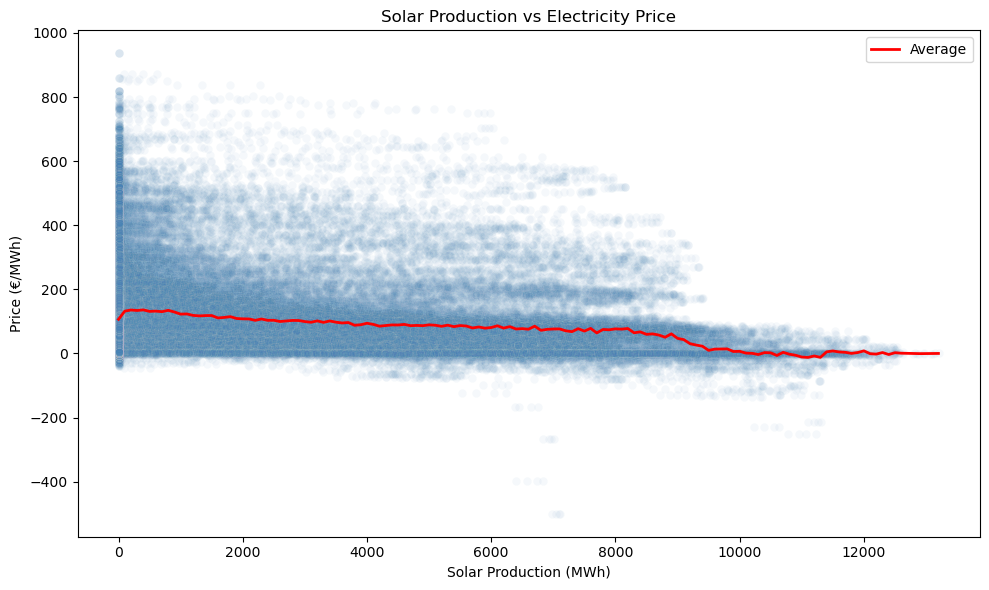

In [29]:
import numpy as np

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="solar", y="price_de", alpha=0.05, color="steelblue")

df_avg = df.groupby(df["solar"].round(-2))["price_de"].mean().reset_index()
plt.plot(df_avg["solar"], df_avg["price_de"], color="red", linewidth=2, label="Average")

plt.title("Solar Production vs Electricity Price")
plt.xlabel("Solar Production (MWh)")
plt.ylabel("Price (€/MWh)")
plt.legend()
plt.tight_layout()
plt.show()

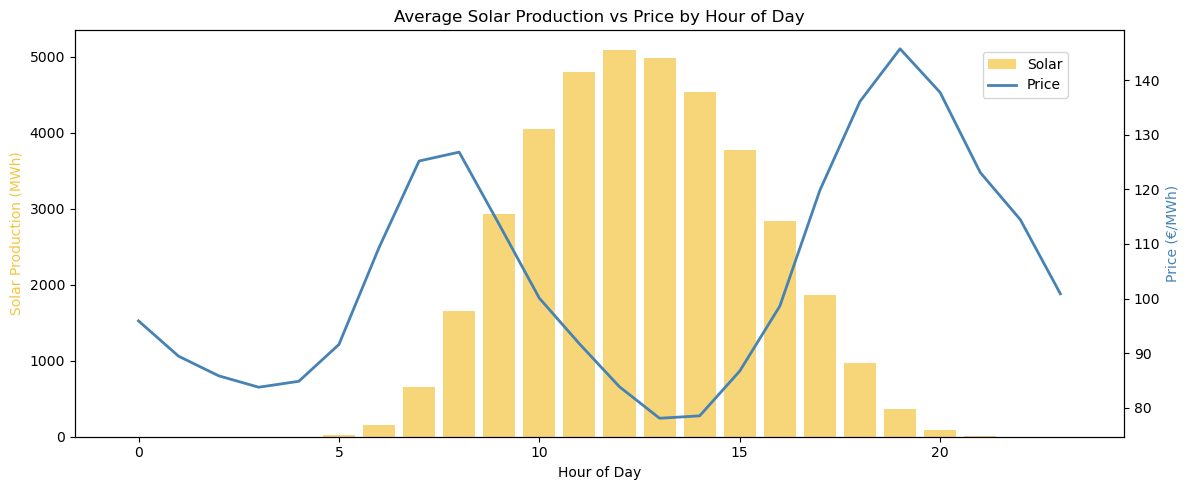

In [30]:
df["hour"] = df["datetime_from"].dt.hour

df_hourly = df.groupby("hour")[["solar", "price_de"]].mean().reset_index()

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.bar(df_hourly["hour"], df_hourly["solar"], color="#f4c542", alpha=0.7, label="Solar")
ax1.set_xlabel("Hour of Day")
ax1.set_ylabel("Solar Production (MWh)", color="#f4c542")

ax2 = ax1.twinx()
ax2.plot(df_hourly["hour"], df_hourly["price_de"], color="steelblue", linewidth=2, label="Price")
ax2.set_ylabel("Price (€/MWh)", color="steelblue")

plt.title("Average Solar Production vs Price by Hour of Day")
fig.legend(loc="upper right", bbox_to_anchor=(0.9, 0.9))
plt.tight_layout()
plt.show()

In [31]:
df["solar_revenue"] = df["solar"] * df["price_de"]

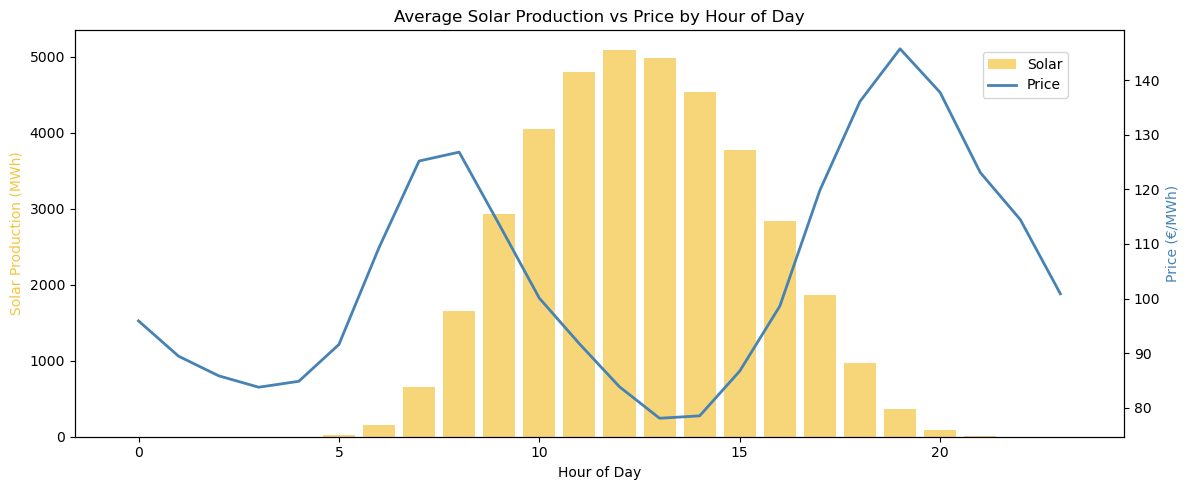

In [32]:
df["hour"] = df["datetime_from"].dt.hour

df_hourly = df.groupby("hour")[["solar", "price_de"]].mean().reset_index()

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.bar(df_hourly["hour"], df_hourly["solar"], color="#f4c542", alpha=0.7, label="Solar")
ax1.set_xlabel("Hour of Day")
ax1.set_ylabel("Solar Production (MWh)", color="#f4c542")

ax2 = ax1.twinx()
ax2.plot(df_hourly["hour"], df_hourly["price_de"], color="steelblue", linewidth=2, label="Price")
ax2.set_ylabel("Price (€/MWh)", color="steelblue")

plt.title("Average Solar Production vs Price by Hour of Day")
fig.legend(loc="upper right", bbox_to_anchor=(0.9, 0.9))
plt.tight_layout()
plt.show()

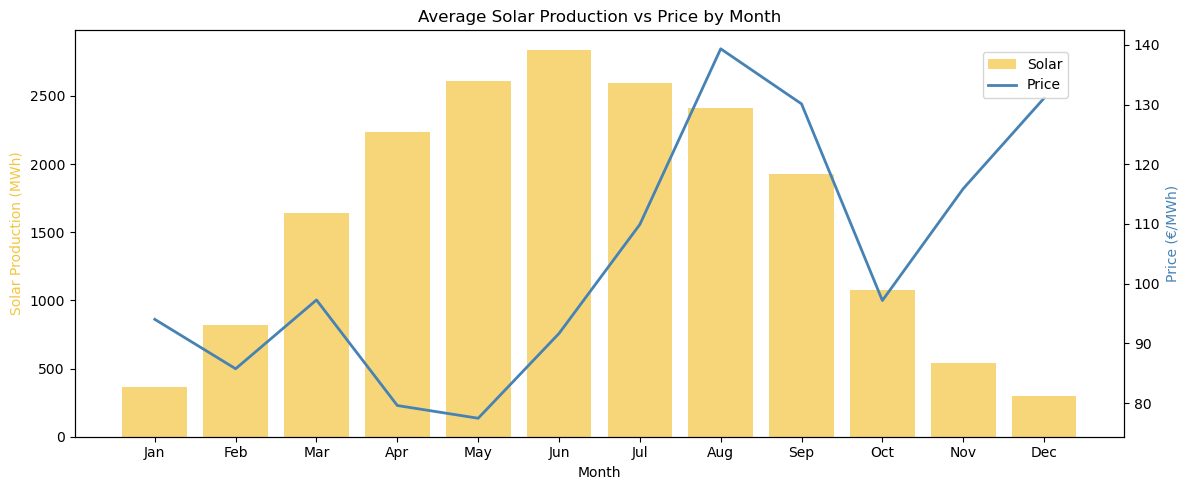

In [33]:
df["month"] = df["datetime_from"].dt.month

df_monthly = df.groupby("month")[["solar", "price_de"]].mean().reset_index()

month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", 
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.bar(df_monthly["month"], df_monthly["solar"], color="#f4c542", alpha=0.7, label="Solar")
ax1.set_xlabel("Month")
ax1.set_ylabel("Solar Production (MWh)", color="#f4c542")
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(month_names)

ax2 = ax1.twinx()
ax2.plot(df_monthly["month"], df_monthly["price_de"], color="steelblue", linewidth=2, label="Price")
ax2.set_ylabel("Price (€/MWh)", color="steelblue")

plt.title("Average Solar Production vs Price by Month")
fig.legend(loc="upper right", bbox_to_anchor=(0.9, 0.9))
plt.tight_layout()
plt.show()

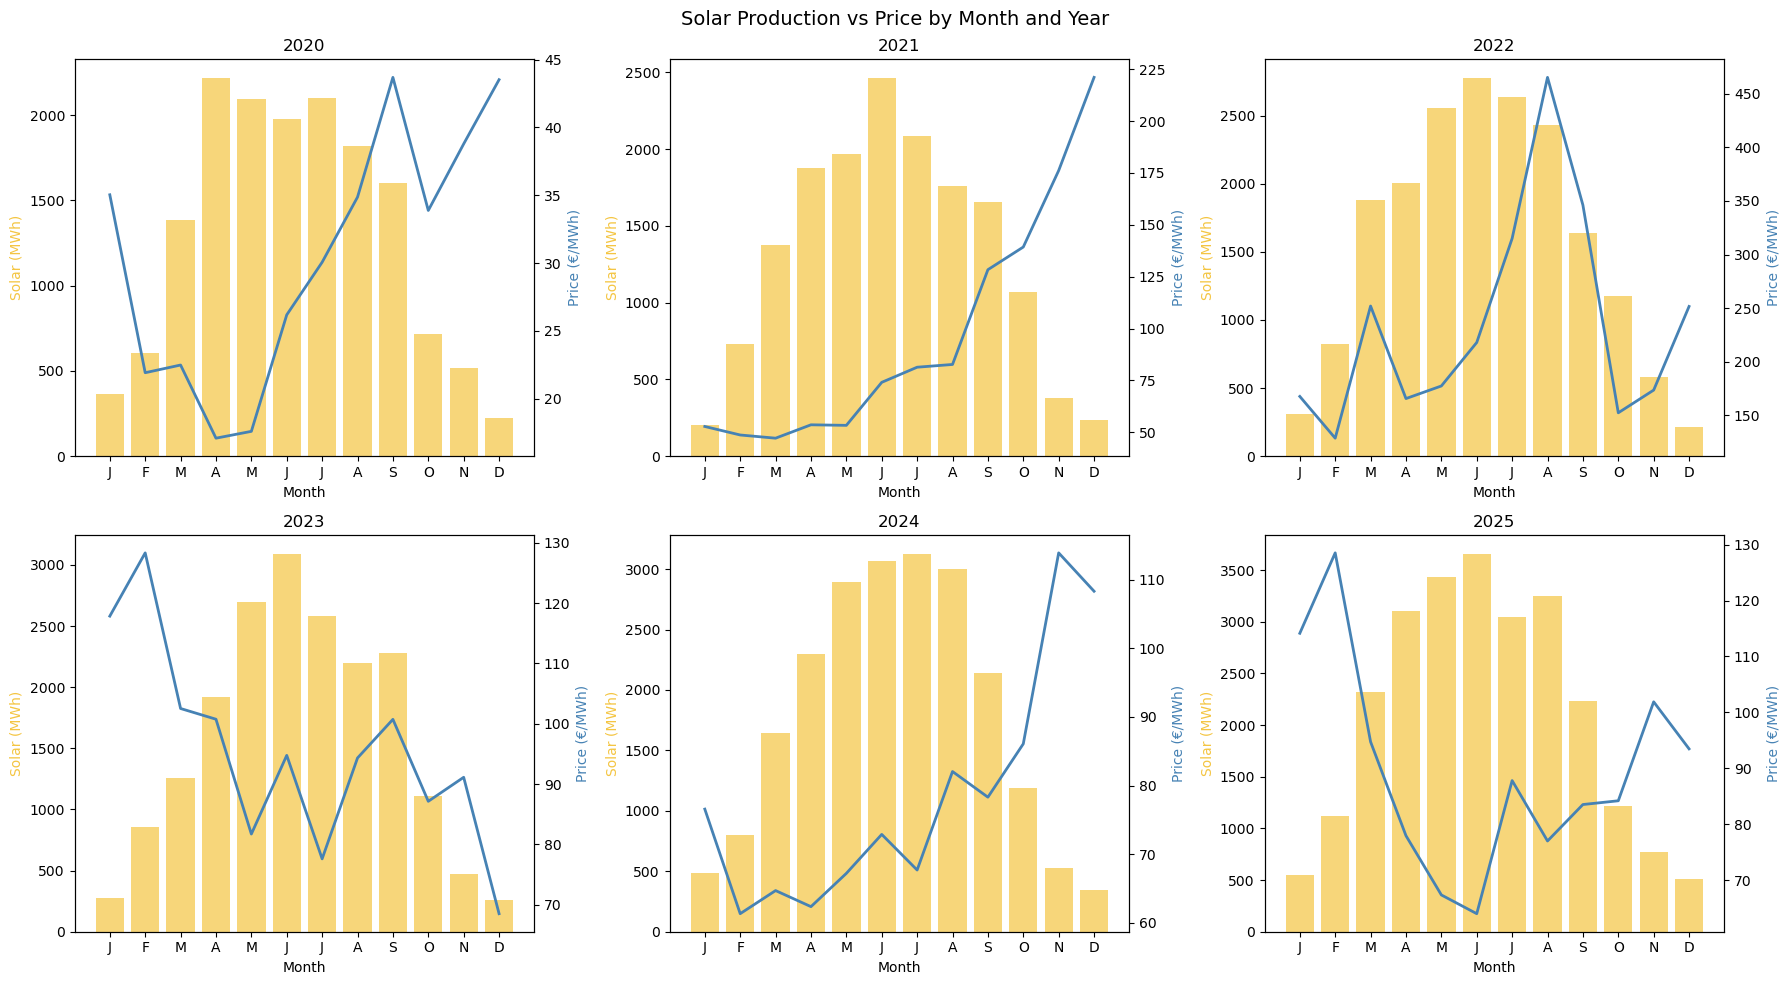

In [34]:
df_monthly_yearly = df.groupby(["year", "month"])[["solar", "price_de"]].mean().reset_index()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, year in enumerate(sorted(df["year"].unique())):
    data = df_monthly_yearly[df_monthly_yearly["year"] == year]
    
    ax1 = axes[i]
    ax1.bar(data["month"], data["solar"], color="#f4c542", alpha=0.7, label="Solar")
    ax1.set_xlabel("Month")
    ax1.set_ylabel("Solar (MWh)", color="#f4c542")
    ax1.set_xticks(range(1, 13))
    ax1.set_xticklabels(["J","F","M","A","M","J","J","A","S","O","N","D"])
    
    ax2 = ax1.twinx()
    ax2.plot(data["month"], data["price_de"], color="steelblue", linewidth=2, label="Price")
    ax2.set_ylabel("Price (€/MWh)", color="steelblue")
    
    ax1.set_title(str(year))

plt.suptitle("Solar Production vs Price by Month and Year", fontsize=14)
plt.tight_layout()
plt.show()

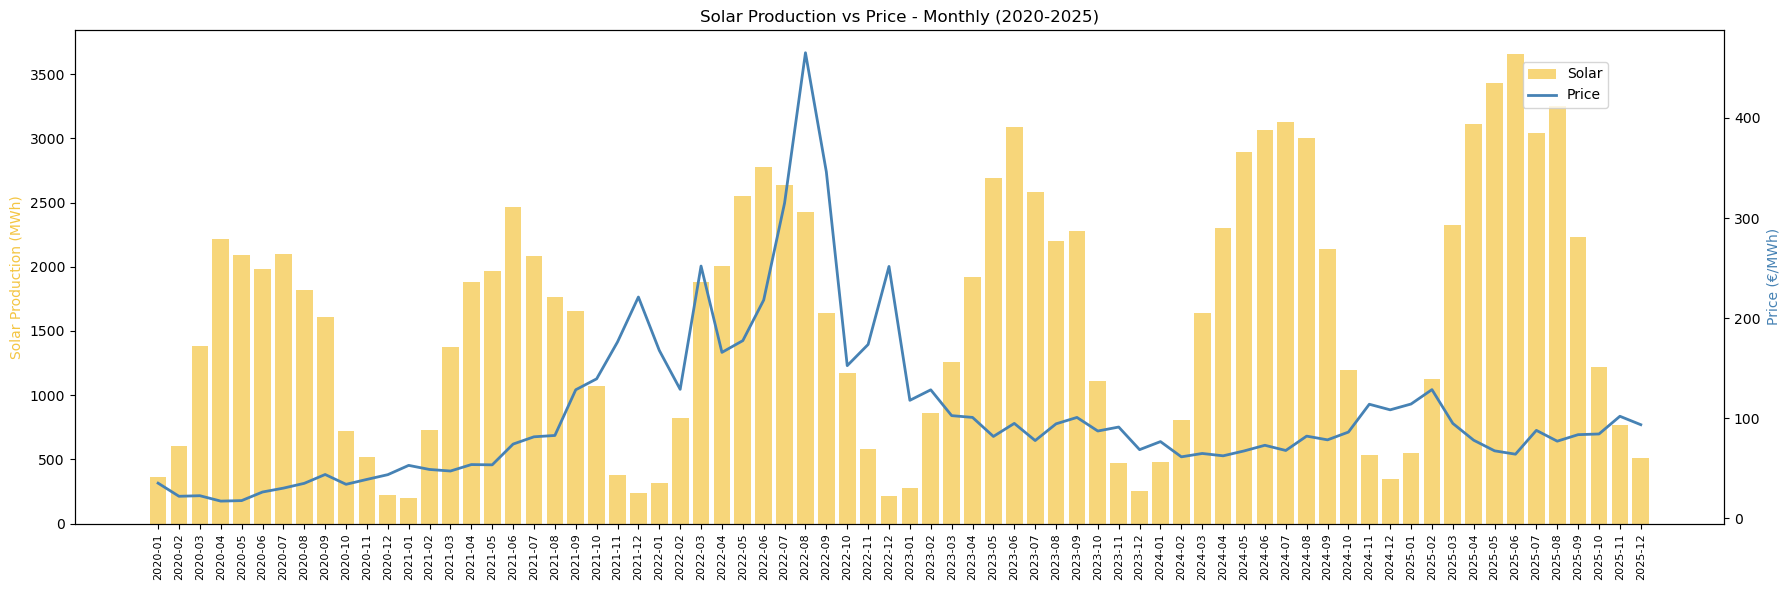

In [35]:
df["year_month"] = df["datetime_from"].dt.to_period("M")
df_monthly_all = df.groupby("year_month")[["solar", "price_de"]].mean().reset_index()
df_monthly_all["year_month_str"] = df_monthly_all["year_month"].astype(str)

fig, ax1 = plt.subplots(figsize=(18, 6))

ax1.bar(range(len(df_monthly_all)), df_monthly_all["solar"], color="#f4c542", alpha=0.7, label="Solar")
ax1.set_ylabel("Solar Production (MWh)", color="#f4c542")

ax2 = ax1.twinx()
ax2.plot(range(len(df_monthly_all)), df_monthly_all["price_de"], color="steelblue", linewidth=2, label="Price")
ax2.set_ylabel("Price (€/MWh)", color="steelblue")

ax1.set_xticks(range(len(df_monthly_all)))
ax1.set_xticklabels(df_monthly_all["year_month_str"], rotation=90, fontsize=8)

plt.title("Solar Production vs Price - Monthly (2020-2025)")
fig.legend(loc="upper right", bbox_to_anchor=(0.9, 0.9))
plt.tight_layout()
plt.show()

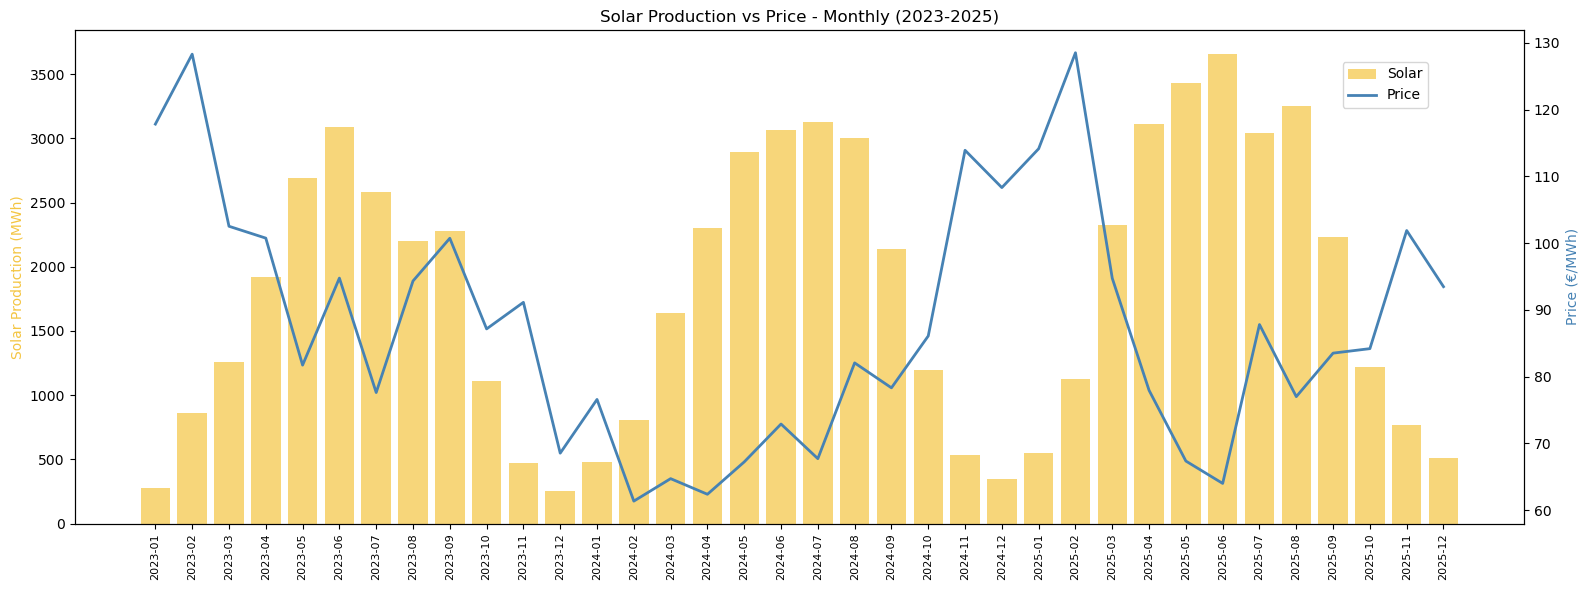

In [36]:
df_recent = df[df["year"] >= 2023]
df_monthly_recent = df_recent.groupby("year_month")[["solar", "price_de"]].mean().reset_index()
df_monthly_recent["year_month_str"] = df_monthly_recent["year_month"].astype(str)

fig, ax1 = plt.subplots(figsize=(16, 6))

ax1.bar(range(len(df_monthly_recent)), df_monthly_recent["solar"], color="#f4c542", alpha=0.7, label="Solar")
ax1.set_ylabel("Solar Production (MWh)", color="#f4c542")

ax2 = ax1.twinx()
ax2.plot(range(len(df_monthly_recent)), df_monthly_recent["price_de"], color="steelblue", linewidth=2, label="Price")
ax2.set_ylabel("Price (€/MWh)", color="steelblue")

ax1.set_xticks(range(len(df_monthly_recent)))
ax1.set_xticklabels(df_monthly_recent["year_month_str"], rotation=90, fontsize=8)

plt.title("Solar Production vs Price - Monthly (2023-2025)")
fig.legend(loc="upper right", bbox_to_anchor=(0.9, 0.9))
plt.tight_layout()
plt.show()

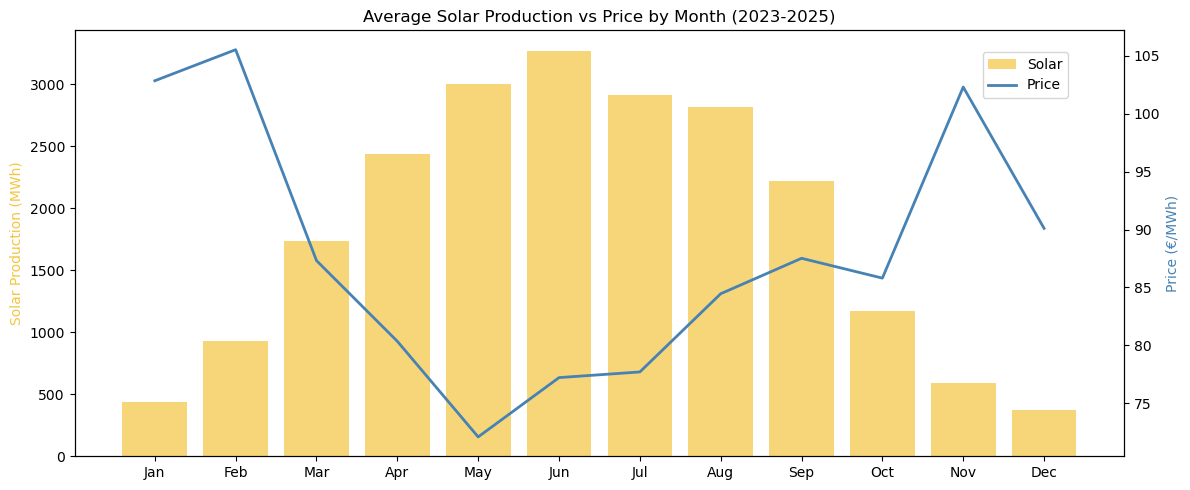

In [37]:
df_recent = df[df["year"] >= 2023]
df_seasonal = df_recent.groupby("month")[["solar", "price_de"]].mean().reset_index()

month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", 
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.bar(df_seasonal["month"], df_seasonal["solar"], color="#f4c542", alpha=0.7, label="Solar")
ax1.set_ylabel("Solar Production (MWh)", color="#f4c542")
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(month_names)

ax2 = ax1.twinx()
ax2.plot(df_seasonal["month"], df_seasonal["price_de"], color="steelblue", linewidth=2, label="Price")
ax2.set_ylabel("Price (€/MWh)", color="steelblue")

plt.title("Average Solar Production vs Price by Month (2023-2025)")
fig.legend(loc="upper right", bbox_to_anchor=(0.9, 0.9))
plt.tight_layout()
plt.show()

In [38]:
df.to_csv("germany_electricity_clean.csv", index=False)
print("Done!")

Done!


## Key Findings
- Solar production nearly doubled between 2020-2025
- Higher solar output consistently correlates with lower electricity prices
- Intraday: prices peak at 19:00 when solar output drops to zero
- Since 2023, renewable energy surpassed fossil fuel production in Germany